In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

In [ ]:
data = pd.read_csv("adult 3.csv")

data.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


In [ ]:
data.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
data.shape

(48842, 15)

In [ ]:
for col in data.columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

In [ ]:
data.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [ ]:
data.duplicated().sum()

52

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
data.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [ ]:
data.tail(20)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48822,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K
48823,72,?,129912,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,0,25,United-States,<=50K
48824,45,Local-gov,119199,Assoc-acdm,12,Divorced,Prof-specialty,Unmarried,White,Female,0,0,48,United-States,<=50K
48825,31,Private,199655,Masters,14,Divorced,Other-service,Not-in-family,Other,Female,0,0,30,United-States,<=50K
48826,39,Local-gov,111499,Assoc-acdm,12,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,>50K
48827,37,Private,198216,Assoc-acdm,12,Divorced,Tech-support,Not-in-family,White,Female,0,0,40,United-States,<=50K
48828,43,Private,260761,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,Mexico,<=50K
48829,65,Self-emp-not-inc,99359,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,1086,0,60,United-States,<=50K
48830,43,State-gov,255835,Some-college,10,Divorced,Adm-clerical,Other-relative,White,Female,0,0,40,United-States,<=50K
48831,43,Self-emp-not-inc,27242,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,<=50K


In [ ]:
#checking for null values 
data.isna()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48838,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48839,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48840,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
data.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [ ]:
print(data.workclass.value_counts())

workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


In [ ]:
data.replace('?', np.nan, inplace=True)
for col in data.columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

In [ ]:
print(data['occupation'].value_counts())

occupation
Prof-specialty       8970
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales                5501
Other-service        4919
Machine-op-inspct    3017
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1485
Tech-support         1445
Protective-serv       982
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64


In [ ]:
data['occupation'] = data['occupation'].replace('?', 'Others')
print(data['occupation'].value_counts())

occupation
Prof-specialty       8970
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales                5501
Other-service        4919
Machine-op-inspct    3017
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1485
Tech-support         1445
Protective-serv       982
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64


In [ ]:
data=data[data['workclass']!='Without-pay']
data=data[data['workclass']!='Never-worked']
print(data['workclass'].value_counts())

workclass
Private             36655
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Name: count, dtype: int64


In [ ]:
print(data.relationship.value_counts())

relationship
Husband           19695
Not-in-family     12556
Own-child          7554
Unmarried          5122
Wife               2327
Other-relative     1505
Name: count, dtype: int64


In [ ]:
print(data.gender.value_counts())

gender
Male      32593
Female    16166
Name: count, dtype: int64


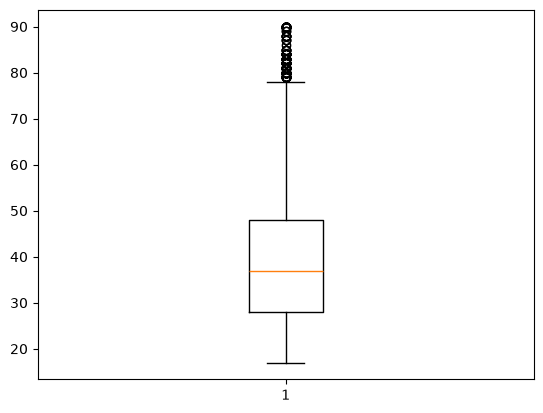

In [ ]:
#outlier detection
import matplotlib.pyplot as plt   #visualization
plt.boxplot(data['age'])
plt.show()

In [ ]:
data=data[(data['age']<=75)&(data['age']>=17)]

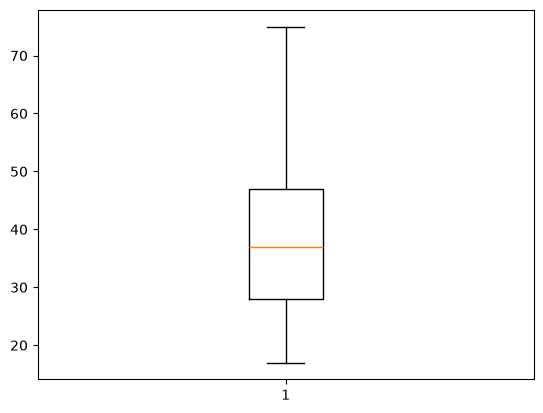

In [ ]:
plt.boxplot(data['age'])
plt.show()

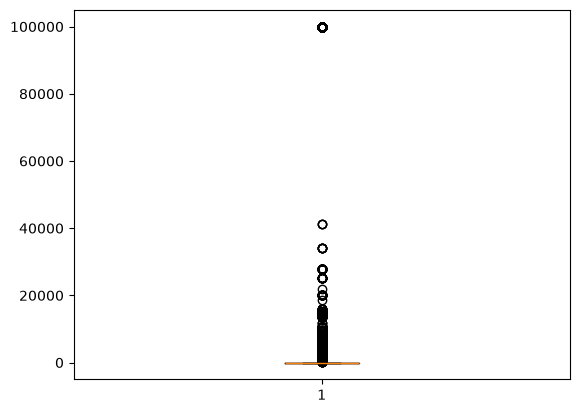

In [ ]:
plt.boxplot(data['capital-gain'])
plt.show()

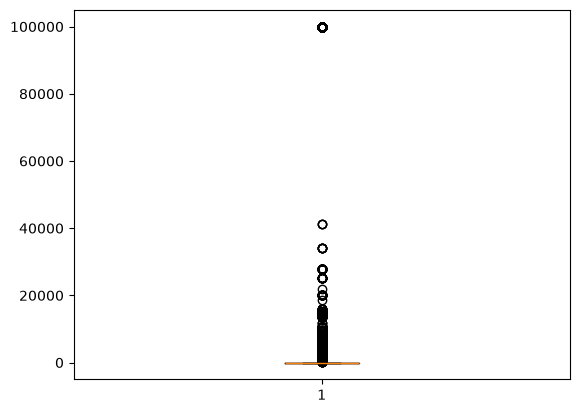

In [ ]:
plt.boxplot(data['capital-gain'])
plt.show()

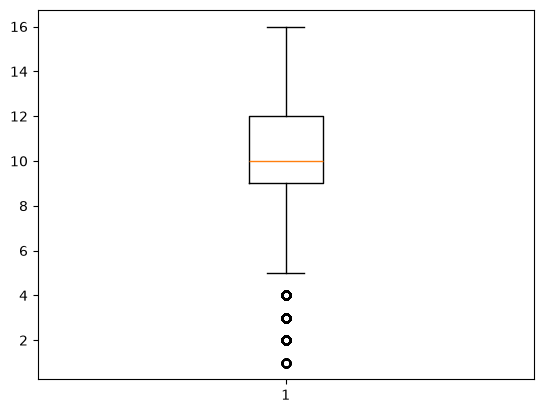

In [ ]:
plt.boxplot(data['educational-num'])
plt.show()

In [ ]:
data=data[(data['educational-num']<=16)&(data['educational-num']>=5)]

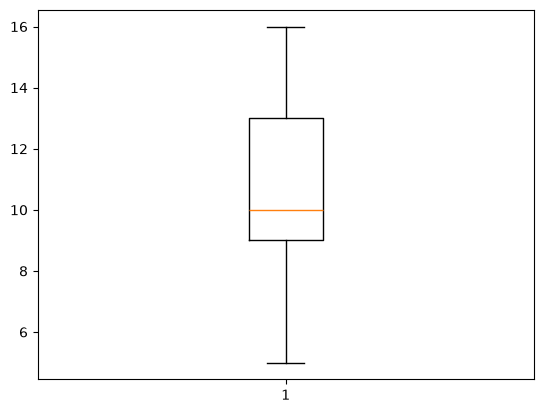

In [ ]:
plt.boxplot(data['educational-num'])
plt.show()

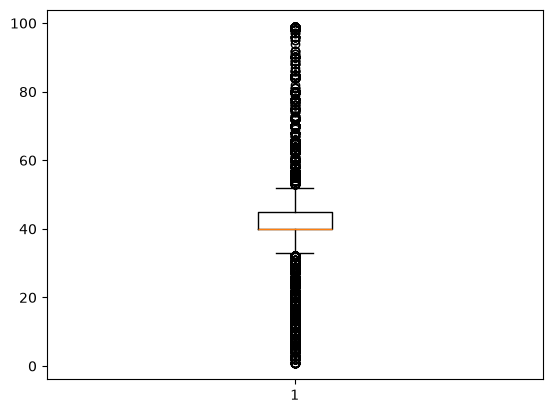

In [ ]:
plt.boxplot(data['hours-per-week'])
plt.show()


In [ ]:
data.shape

(46676, 15)

In [ ]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
#Encode all categorical columns except the target
encoder=LabelEncoder()                       #create object
data['workclass']=encoder.fit_transform(data['workclass']) #7 categories   0,1, 2, 3, 4, 5, 6,
data['marital-status']=encoder.fit_transform(data['marital-status'])   #3 categories 0, 1, 2
data['occupation']=encoder.fit_transform(data['occupation'])
data['relationship']=encoder.fit_transform(data['relationship'])      #5 categories  0, 1, 2, 3, 4
 
data['gender']=encoder.fit_transform(data['gender'])    #2 catogories     0, 1
data['native-country']=encoder.fit_transform(data['native-country'])

In [ ]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,226802,11th,7,4,6,3,Black,1,0,0,40,38,<=50K
1,38,2,89814,HS-grad,9,2,4,0,White,1,0,0,50,38,<=50K
2,28,1,336951,Assoc-acdm,12,2,10,0,White,1,0,0,40,38,>50K
3,44,2,160323,Some-college,10,2,6,0,Black,1,7688,0,40,38,>50K
4,18,2,103497,Some-college,10,4,9,3,White,0,0,0,30,38,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,2,257302,Assoc-acdm,12,2,12,5,White,0,0,0,38,38,<=50K
48838,40,2,154374,HS-grad,9,2,6,0,White,1,0,0,40,38,>50K
48839,58,2,151910,HS-grad,9,6,0,4,White,0,0,0,40,38,<=50K
48840,22,2,201490,HS-grad,9,4,0,3,White,1,0,0,20,38,<=50K


In [ ]:
data.shape

(46676, 15)

In [ ]:
x=data.drop(columns=['income'])
y=data['income']
x

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,2,226802,11th,7,4,6,3,Black,1,0,0,40,38
1,38,2,89814,HS-grad,9,2,4,0,White,1,0,0,50,38
2,28,1,336951,Assoc-acdm,12,2,10,0,White,1,0,0,40,38
3,44,2,160323,Some-college,10,2,6,0,Black,1,7688,0,40,38
4,18,2,103497,Some-college,10,4,9,3,White,0,0,0,30,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,2,257302,Assoc-acdm,12,2,12,5,White,0,0,0,38,38
48838,40,2,154374,HS-grad,9,2,6,0,White,1,0,0,40,38
48839,58,2,151910,HS-grad,9,6,0,4,White,0,0,0,40,38
48840,22,2,201490,HS-grad,9,4,0,3,White,1,0,0,20,38


In [ ]:
label = LabelEncoder()
data['income'] = label.fit_transform(data['income'])

In [ ]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,226802,11th,7,4,6,3,Black,1,0,0,40,38,0
1,38,2,89814,HS-grad,9,2,4,0,White,1,0,0,50,38,0
2,28,1,336951,Assoc-acdm,12,2,10,0,White,1,0,0,40,38,1
3,44,2,160323,Some-college,10,2,6,0,Black,1,7688,0,40,38,1
4,18,2,103497,Some-college,10,4,9,3,White,0,0,0,30,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,2,257302,Assoc-acdm,12,2,12,5,White,0,0,0,38,38,0
48838,40,2,154374,HS-grad,9,2,6,0,White,1,0,0,40,38,1
48839,58,2,151910,HS-grad,9,6,0,4,White,0,0,0,40,38,0
48840,22,2,201490,HS-grad,9,4,0,3,White,1,0,0,20,38,0


In [ ]:
# Remove outliers from capital gain and loss
for col in ['capital-gain', 'capital-loss']:
    quartile1= data[col].quantile(0.25)
    quartile2 = data[col].quantile(0.75)
    interquartilerange= quartile2 - quartile1
    data = data[(data[col] >= quartile1- 1.5 * interquartilerange) & (data[col] <= quartile2 + 1.5 * interquartilerange)]


In [ ]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,226802,11th,7,4,6,3,Black,1,0,0,40,38,0
1,38,2,89814,HS-grad,9,2,4,0,White,1,0,0,50,38,0
2,28,1,336951,Assoc-acdm,12,2,10,0,White,1,0,0,40,38,1
4,18,2,103497,Some-college,10,4,9,3,White,0,0,0,30,38,0
5,34,2,198693,10th,6,4,7,1,White,1,0,0,30,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,22,2,310152,Some-college,10,4,10,1,White,1,0,0,40,38,0
48837,27,2,257302,Assoc-acdm,12,2,12,5,White,0,0,0,38,38,0
48838,40,2,154374,HS-grad,9,2,6,0,White,1,0,0,40,38,1
48839,58,2,151910,HS-grad,9,6,0,4,White,0,0,0,40,38,0


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

# Convert target variable
data["income"] = data["income"].replace({"<=50K": 0, ">50K": 1})

# Features and Target
X = data.drop("income", axis=1)
y = data["income"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Numerical and Categorical Columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

# Numerical Pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

# ===============================
# Logistic Regression
# ===============================

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# ===============================
# Random Forest
# ===============================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("="*60)
print("RANDOM FOREST")
print("="*60)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# ===============================
# KNN
# ===============================

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

knn_pred = knn_pipeline.predict(X_test)

print("="*60)
print("KNN")
print("="*60)

print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

C:\Users\vinee\AppData\Local\Temp\ipykernel_8512\2765805661.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


LOGISTIC REGRESSION
Accuracy: 0.8094123444622398
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      6528
           1       0.53      0.20      0.29      1589

    accuracy                           0.81      8117
   macro avg       0.68      0.58      0.59      8117
weighted avg       0.77      0.81      0.77      8117

RANDOM FOREST
Accuracy: 0.7794751755574719
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      6528
           1       0.42      0.32      0.36      1589

    accuracy                           0.78      8117
   macro avg       0.63      0.61      0.62      8117
weighted avg       0.76      0.78      0.77      8117

KNN
Accuracy: 0.7925341875076999
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      6528
           1       0.46      0.31      0.37      1589

    accuracy                           0.79      8117
   

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

# ==========================
# Target Variable
# ==========================

data["income"] = data["income"].replace({"<=50K": 0, ">50K": 1})

# Features and Target
X = data.drop("income", axis=1)
y = data["income"]

# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# Feature Types
# ==========================

numerical_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# ==========================
# Preprocessing Pipelines
# ==========================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# ============================================================
# Logistic Regression
# ============================================================

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)
print("Accuracy :", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# ============================================================
# Random Forest
# ============================================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print("Accuracy :", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# ============================================================
# KNN
# ============================================================

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

knn_pred = knn_pipeline.predict(X_test)

print("=" * 60)
print("K-NEAREST NEIGHBORS")
print("=" * 60)
print("Accuracy :", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

LOGISTIC REGRESSION
Accuracy : 0.8234569422200321
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      6528
           1       0.60      0.28      0.39      1589

    accuracy                           0.82      8117
   macro avg       0.72      0.62      0.64      8117
weighted avg       0.80      0.82      0.80      8117

RANDOM FOREST
Accuracy : 0.8376247382037698
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6528
           1       0.61      0.47      0.53      1589

    accuracy                           0.84      8117
   macro avg       0.74      0.70      0.72      8117
weighted avg       0.83      0.84      0.83      8117

K-NEAREST NEIGHBORS
Accuracy : 0.8282616730319083
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      6528
           1       0.57      0.50      0.53      1589

    accuracy                          

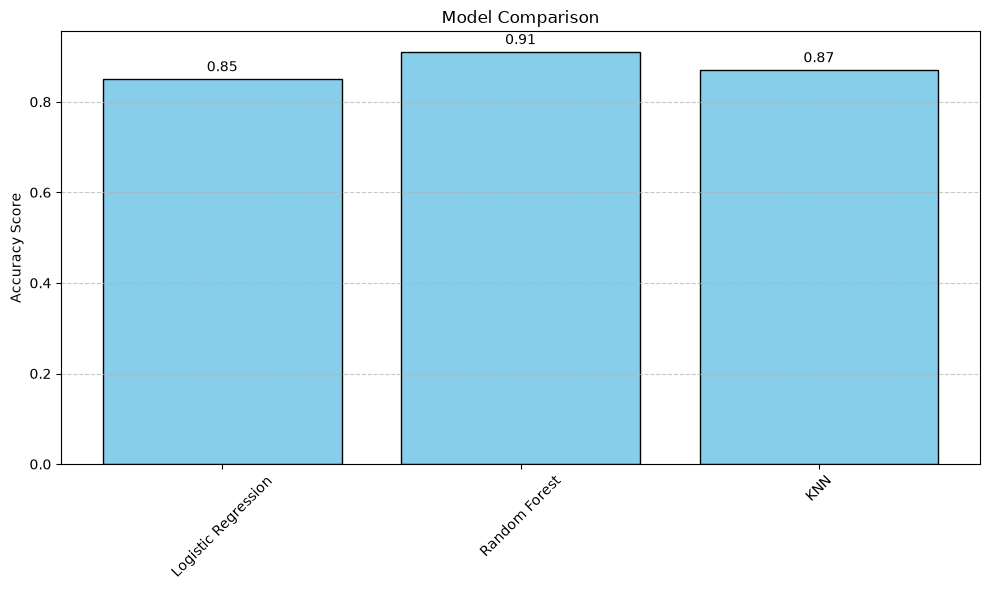

In [ ]:
import matplotlib.pyplot as plt


results = {
    'Logistic Regression': 0.85,
    'Random Forest': 0.91,
    'KNN': 0.87
}

plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color='skyblue', edgecolor='black')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

plt.ylabel('Accuracy Score')
plt.title('Model Comparison')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


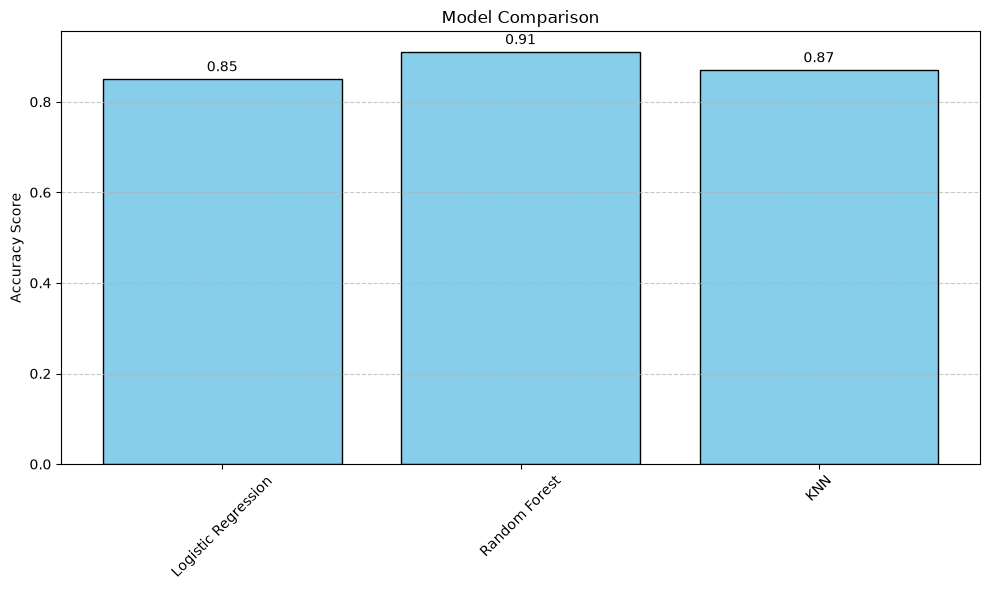

In [ ]:
import matplotlib.pyplot as plt


results = {
    'Logistic Regression': 0.85,
    'Random Forest': 0.91,
    'KNN': 0.87
}

plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color='skyblue', edgecolor='black')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

plt.ylabel('Accuracy Score')
plt.title('Model Comparison')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import joblib




data.replace('?', np.nan, inplace=True)
for col in data.columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])


x = pd.get_dummies(data.drop(columns=['income']), drop_first=True)  
le = LabelEncoder()
y = le.fit_transform(data['income'])  


scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)


models = {
    "LogisticRegression": LogisticRegression(max_iter=5000),  # Increased iterations
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "GradientBoosting": GradientBoostingClassifier()
}


results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

#Get the best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\n✅ Best model: {best_model_name} with accuracy {results[best_model_name]:.4f}")

#Save the best model and scaler
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("✅ Saved best model as 'best_model.pkl' and scaler as 'scaler.pkl'")


LogisticRegression: 0.8226
RandomForest: 0.8427
KNN: 0.8312
SVM: 0.8402
GradientBoosting: 0.8565

✅ Best model: GradientBoosting with accuracy 0.8565
✅ Saved best model as 'best_model.pkl' and scaler as 'scaler.pkl'


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load the trained model
model = joblib.load("best_model.pkl")

st.set_page_config(page_title="Employee Salary Classification", page_icon="💼", layout="centered")

st.title("💼 Employee Salary Classification App")
st.markdown("Predict whether an employee earns >50K or ≤50K based on input features.")


st.sidebar.header("Input Employee Details")


age = st.sidebar.slider("Age", 18, 65, 30)
education = st.sidebar.selectbox("Education Level", [
    "Bachelors", "Masters", "PhD", "HS-grad", "Assoc", "Some-college"
])
occupation = st.sidebar.selectbox("Job Role", [
    "Tech-support", "Craft-repair", "Other-service", "Sales",
    "Exec-managerial", "Prof-specialty", "Handlers-cleaners", "Machine-op-inspct",
    "Adm-clerical", "Farming-fishing", "Transport-moving", "Priv-house-serv",
    "Protective-serv", "Armed-Forces"
])
hours_per_week = st.sidebar.slider("Hours per week", 1, 80, 40)
experience = st.sidebar.slider("Years of Experience", 0, 40, 5)

# Build input DataFrame
input_df = pd.DataFrame({
    'age': [age],
    'education': [education],
    'occupation': [occupation],
    'hours-per-week': [hours_per_week],
    'experience': [experience]
})

st.write("### 🔎 Input Data")
st.write(input_df)

# Predict button
if st.button("Predict Salary Class"):
    prediction = model.predict(input_df)
    st.success(f"✅ Prediction: {prediction[0]}")

# Batch prediction
st.markdown("---")
st.markdown("#### 📂 Batch Prediction")
uploaded_file = st.file_uploader("Upload a CSV file for batch prediction", type="csv")

if uploaded_file is not None:
    batch_data = pd.read_csv(uploaded_file)
    st.write("Uploaded data preview:", batch_data.head())
    batch_preds = model.predict(batch_data)
    batch_data['PredictedClass'] = batch_preds
    st.write("✅ Predictions:")
    st.write(batch_data.head())
    csv = batch_data.to_csv(index=False).encode('utf-8')
    st.download_button("Download Predictions CSV", csv, file_name='predicted_classes.csv', mime='text/csv')

Writing app.py


In [ ]:
data


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,226802,11th,7,4,6,3,Black,1,0,0,40,38,0
1,38,2,89814,HS-grad,9,2,4,0,White,1,0,0,50,38,0
2,28,1,336951,Assoc-acdm,12,2,10,0,White,1,0,0,40,38,1
4,18,2,103497,Some-college,10,4,9,3,White,0,0,0,30,38,0
5,34,2,198693,10th,6,4,7,1,White,1,0,0,30,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,22,2,310152,Some-college,10,4,10,1,White,1,0,0,40,38,0
48837,27,2,257302,Assoc-acdm,12,2,12,5,White,0,0,0,38,38,0
48838,40,2,154374,HS-grad,9,2,6,0,White,1,0,0,40,38,1
48839,58,2,151910,HS-grad,9,6,0,4,White,0,0,0,40,38,0


In [ ]:
data.shape

(40581, 15)

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib


# Load model and training columns
model = joblib.load("best_model.pkl")
training_columns = joblib.load("columns.pkl")


st.set_page_config(
    page_title="Employee Salary Classification",
    page_icon="💼",
    layout="centered"
)


st.title("💼 Employee Salary Classification App")

st.markdown(
    "Predict whether an employee earns >50K or ≤50K based on input features."
)


st.sidebar.header("Input Employee Details")


# User Inputs

age = st.sidebar.slider(
    "Age",
    18,
    65,
    30
)


education = st.sidebar.selectbox(
    "Education Level",
    [
        "Bachelors",
        "Masters",
        "PhD",
        "HS-grad",
        "Assoc",
        "Some-college"
    ]
)


occupation = st.sidebar.selectbox(
    "Job Role",
    [
        "Tech-support",
        "Craft-repair",
        "Other-service",
        "Sales",
        "Exec-managerial",
        "Prof-specialty",
        "Handlers-cleaners",
        "Machine-op-inspct",
        "Adm-clerical",
        "Farming-fishing",
        "Transport-moving",
        "Priv-house-serv",
        "Protective-serv",
        "Armed-Forces"
    ]
)


hours_per_week = st.sidebar.slider(
    "Hours per week",
    1,
    80,
    40
)


experience = st.sidebar.slider(
    "Years of Experience",
    0,
    40,
    5
)



# Create dataframe

input_df = pd.DataFrame(
    {
        "age": [age],
        "education": [education],
        "occupation": [occupation],
        "hours-per-week": [hours_per_week],
        "experience": [experience]
    }
)



st.write("### 🔎 Input Data")
st.write(input_df)



# Preprocessing function

def preprocess_data(df):

    df = df.copy()


    # Convert categorical values using one-hot encoding
    df = pd.get_dummies(df)


    # Add missing training columns
    for col in training_columns:
        if col not in df.columns:
            df[col] = 0


    # Remove unwanted extra columns
    df = df[training_columns]


    return df



# Single Prediction

if st.button("Predict Salary Class"):

    processed_input = preprocess_data(input_df)


    prediction = model.predict(
        processed_input
    )


    if prediction[0] == 1:
        result = ">50K"
    else:
        result = "<=50K"


    st.success(
        f"✅ Prediction: {result}"
    )



# Batch Prediction

st.markdown("---")

st.subheader("📂 Batch Prediction")


uploaded_file = st.file_uploader(
    "Upload CSV file",
    type=["csv"]
)



if uploaded_file is not None:

    batch_data = pd.read_csv(uploaded_file)


    st.write(
        "Uploaded Data:",
        batch_data.head()
    )


    processed_batch = preprocess_data(
        batch_data
    )


    batch_predictions = model.predict(
        processed_batch
    )


    batch_data["PredictedClass"] = batch_predictions


    batch_data["PredictedClass"] = batch_data[
        "PredictedClass"
    ].replace(
        {
            1: ">50K",
            0: "<=50K"
        }
    )


    st.write(
        "✅ Prediction Results:"
    )

    st.write(
        batch_data.head()
    )


    csv = batch_data.to_csv(
        index=False
    ).encode("utf-8")


    st.download_button(
        label="Download Predictions CSV",
        data=csv,
        file_name="salary_predictions.csv",
        mime="text/csv"
    )

Overwriting app.py


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib


# Load trained model
model = joblib.load("best_model.pkl")


st.set_page_config(
    page_title="Employee Salary Classification",
    page_icon="💼",
    layout="centered"
)


st.title("💼 Employee Salary Classification App")
st.markdown(
    "Predict whether an employee earns >50K or ≤50K based on input features."
)


# Get model feature information
expected_features = model.n_features_in_


st.sidebar.header("Input Employee Details")


# User inputs

age = st.sidebar.slider(
    "Age",
    18,
    65,
    30
)


education = st.sidebar.selectbox(
    "Education Level",
    [
        "Bachelors",
        "Masters",
        "PhD",
        "HS-grad",
        "Assoc",
        "Some-college"
    ]
)


occupation = st.sidebar.selectbox(
    "Job Role",
    [
        "Tech-support",
        "Craft-repair",
        "Other-service",
        "Sales",
        "Exec-managerial",
        "Prof-specialty",
        "Handlers-cleaners",
        "Machine-op-inspct",
        "Adm-clerical",
        "Farming-fishing",
        "Transport-moving",
        "Priv-house-serv",
        "Protective-serv",
        "Armed-Forces"
    ]
)


hours_per_week = st.sidebar.slider(
    "Hours per week",
    1,
    80,
    40
)


experience = st.sidebar.slider(
    "Years of Experience",
    0,
    40,
    5
)



# Create dataframe

input_df = pd.DataFrame(
    {
        "age": [age],
        "education": [education],
        "occupation": [occupation],
        "hours-per-week": [hours_per_week],
        "experience": [experience]
    }
)


st.write("### 🔎 Input Data")
st.write(input_df)



# Preprocessing function

def preprocess_data(df):

    df = df.copy()


    # One hot encoding
    df = pd.get_dummies(df)


    # If model expects more features
    if df.shape[1] < expected_features:

        missing_features = expected_features - df.shape[1]

        for i in range(missing_features):
            df[f"missing_feature_{i}"] = 0


    # If extra features exist
    elif df.shape[1] > expected_features:

        df = df.iloc[:, :expected_features]


    return df



# Single prediction

if st.button("Predict Salary Class"):

    processed_input = preprocess_data(input_df)


    prediction = model.predict(
        processed_input
    )


    if prediction[0] == 1:
        result = ">50K"
    else:
        result = "<=50K"


    st.success(
        f"✅ Prediction: {result}"
    )



# Batch prediction

st.markdown("---")

st.subheader("📂 Batch Prediction")


uploaded_file = st.file_uploader(
    "Upload CSV file",
    type=["csv"]
)


if uploaded_file is not None:

    batch_data = pd.read_csv(uploaded_file)


    st.write(
        "Uploaded data preview:",
        batch_data.head()
    )


    processed_batch = preprocess_data(
        batch_data
    )


    batch_preds = model.predict(
        processed_batch
    )


    batch_data["PredictedClass"] = batch_preds


    batch_data["PredictedClass"] = batch_data[
        "PredictedClass"
    ].replace(
        {
            1: ">50K",
            0: "<=50K"
        }
    )


    st.write(
        "✅ Prediction Results:"
    )

    st.write(
        batch_data.head()
    )


    csv = batch_data.to_csv(
        index=False
    ).encode("utf-8")


    st.download_button(
        "Download Predictions CSV",
        csv,
        file_name="salary_predictions.csv",
        mime="text/csv"
    )

Overwriting app.py
